<a href="https://colab.research.google.com/github/sasasaee/ml-project/blob/salsabil/canteen_classification_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier,
    AdaBoostClassifier
)

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

In [3]:
url = "https://raw.githubusercontent.com/sasasaee/ml-project/main/data/canteen_dataset_feature_engineered.csv"

df = pd.read_csv(url)

df.head()

,Waste_Weight_kg,Unit_Price_per_kg,Cost_Loss,Day,Month,Weekend,Day_Number,Meal_Dinner,Meal_Lunch,Food_Category_Rice,...,Canteen_Section_D,Day_of_Week_Monday,Day_of_Week_Saturday,Day_of_Week_Sunday,Day_of_Week_Thursday,Day_of_Week_Tuesday,Day_of_Week_Wednesday,Season_Summer,Price_Category_Medium,Price_Category_High
0,1.50,3.0,4.50,30,7,False,49,True,False,False,...,False,False,False,False,False,False,True,False,False,False
1,3.69,2.0,7.38,15,6,True,4,False,False,True,...,False,False,False,True,False,False,False,False,False,False
2,1.54,1.5,2.31,29,7,False,48,False,False,False,...,False,False,False,False,False,True,False,False,False,False
3,1.81,1.5,2.71,17,7,False,36,False,False,False,...,False,False,False,False,True,False,False,False,False,False
4,4.69,2.0,9.38,3,7,False,22,True,False,True,...,True,False,False,False,True,False,False,False,False,False


In [4]:
df.shape

(2600, 24)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2600 entries, 0 to 2599
Data columns (total 24 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Waste_Weight_kg           2600 non-null   float64
 1   Unit_Price_per_kg         2600 non-null   float64
 2   Cost_Loss                 2600 non-null   float64
 3   Day                       2600 non-null   int64  
 4   Month                     2600 non-null   int64  
 5   Weekend                   2600 non-null   bool   
 6   Day_Number                2600 non-null   int64  
 7   Meal_Dinner               2600 non-null   bool   
 8   Meal_Lunch                2600 non-null   bool   
 9   Food_Category_Rice        2600 non-null   bool   
 10  Food_Category_Soup        2600 non-null   bool   
 11  Food_Category_Vegetables  2600 non-null   bool   
 12  Canteen_Section_B         2600 non-null   bool   
 13  Canteen_Section_C         2600 non-null   bool   
 14  Canteen_

#### Distribution of the raw continuous target

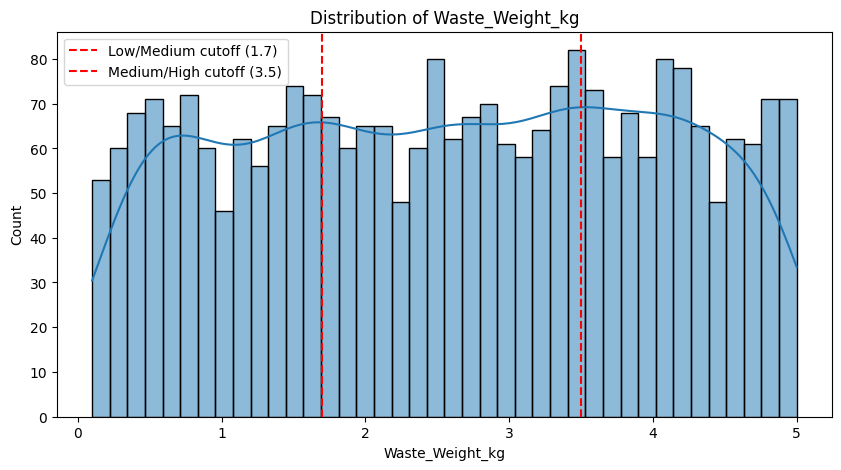

count    2600.000000
mean        2.585988
std         1.408281
min         0.100000
25%         1.390000
50%         2.600000
75%         3.800000
max         5.000000
Name: Waste_Weight_kg, dtype: float64

Quantiles:
0.25    1.39
0.33    1.76
0.50    2.60
0.66    3.39
0.75    3.80
Name: Waste_Weight_kg, dtype: float64


In [6]:
plt.figure(figsize=(10, 5))
sns.histplot(df["Waste_Weight_kg"], bins=40, kde=True)
plt.axvline(1.7, color="red", linestyle="--", label="Low/Medium cutoff (1.7)")
plt.axvline(3.5, color="red", linestyle="--", label="Medium/High cutoff (3.5)")
plt.title("Distribution of Waste_Weight_kg")
plt.legend()
plt.show()

print(df["Waste_Weight_kg"].describe())
print("\nQuantiles:")
print(df["Waste_Weight_kg"].quantile([0.25, 0.33, 0.5, 0.66, 0.75]))

###boxplots of the raw target against your categorical features

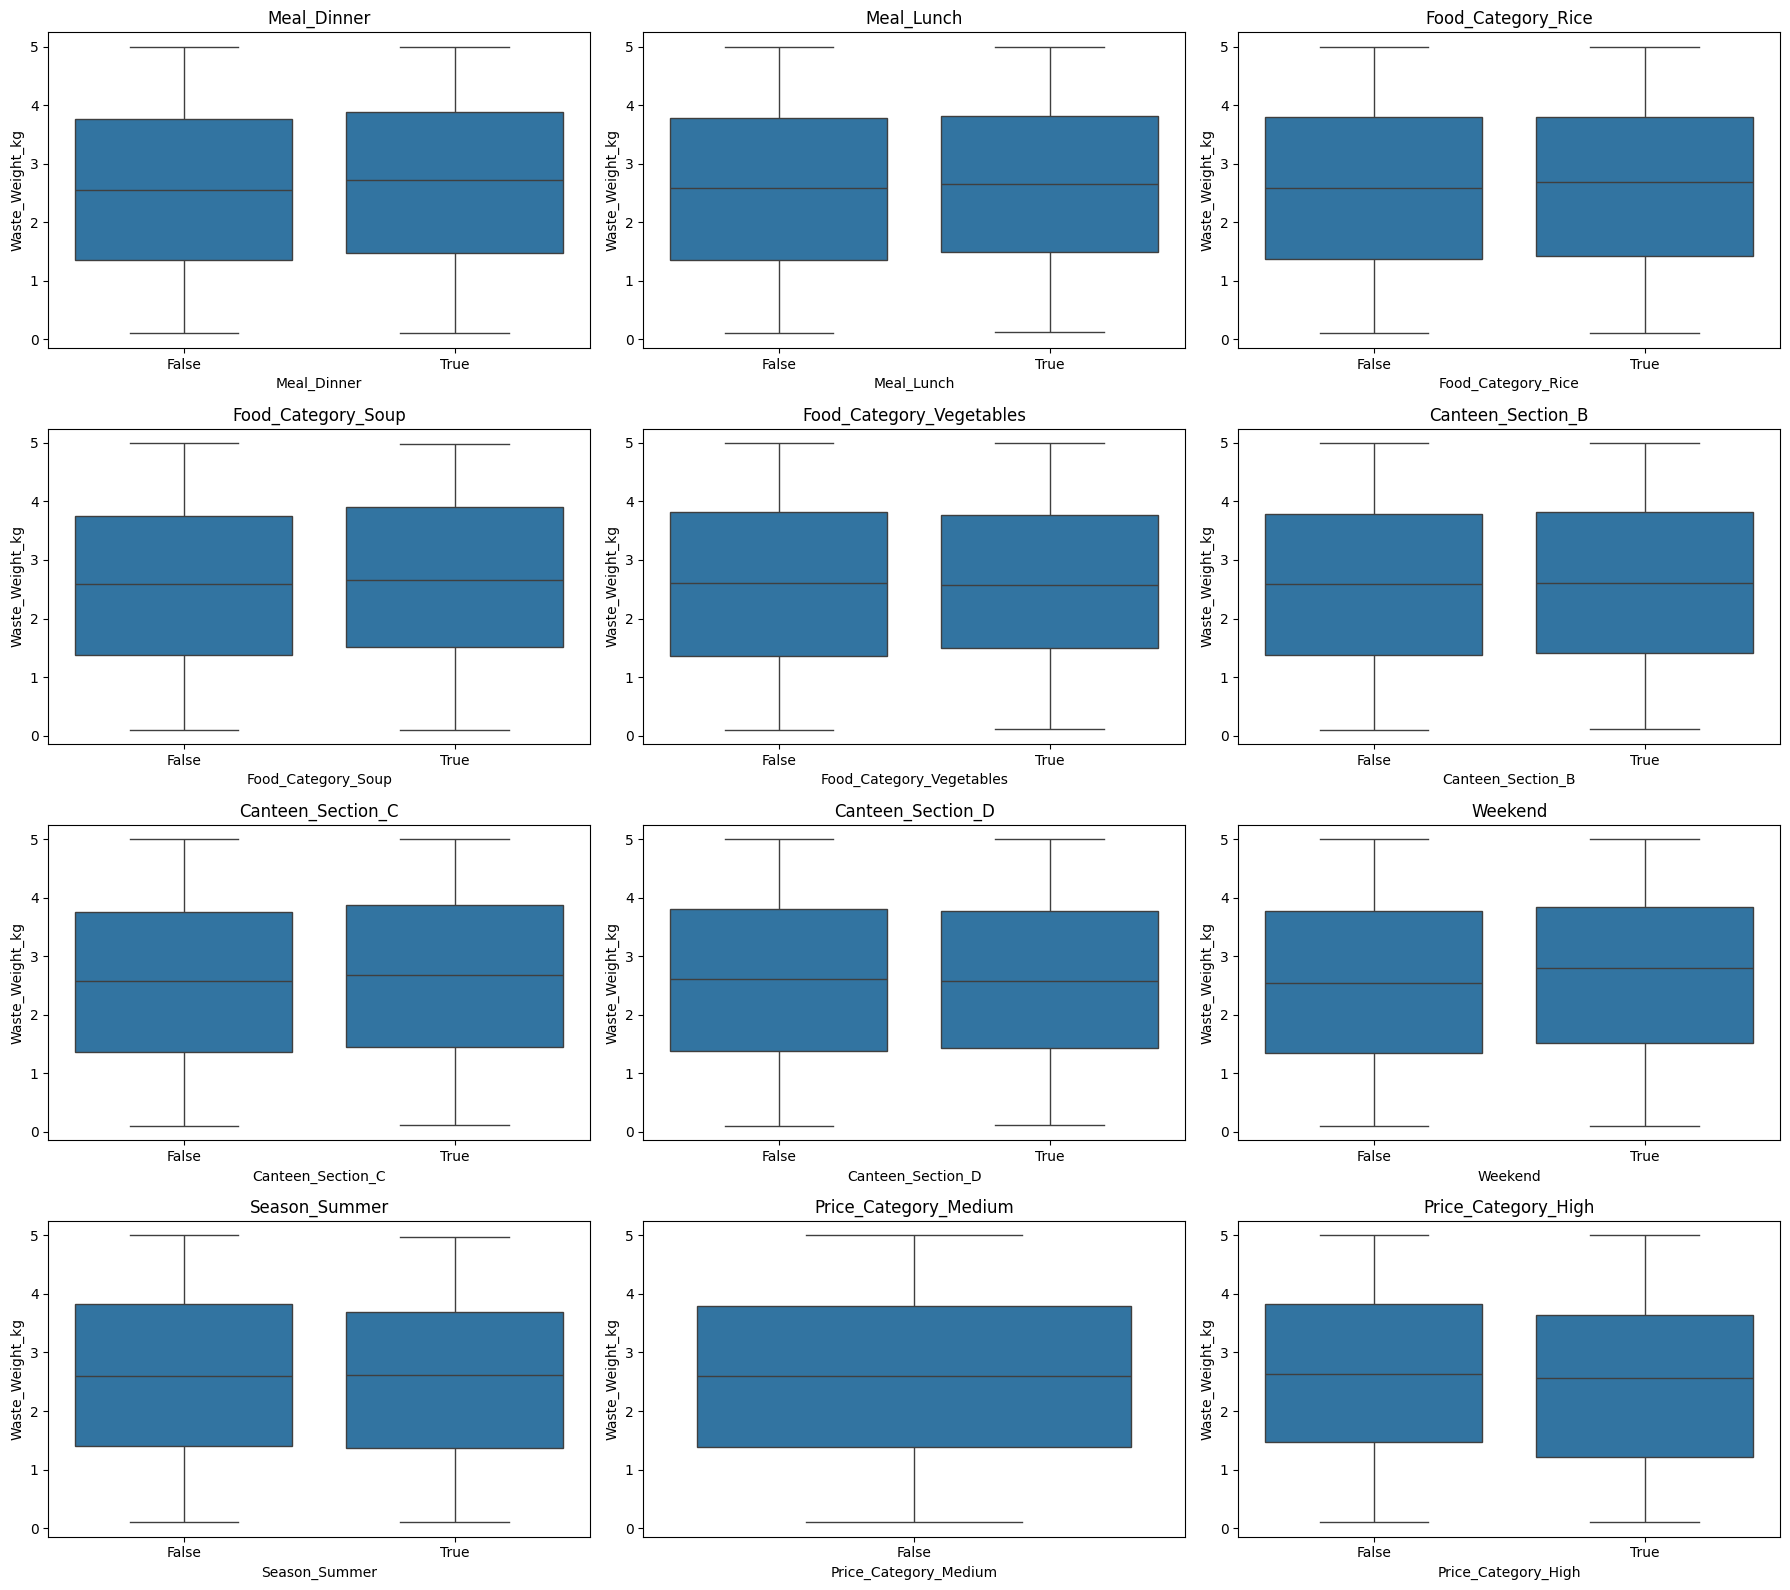

In [7]:
categorical_cols_to_check = [
    "Meal_Dinner", "Meal_Lunch",
    "Food_Category_Rice", "Food_Category_Soup", "Food_Category_Vegetables",
    "Canteen_Section_B", "Canteen_Section_C", "Canteen_Section_D",
    "Weekend", "Season_Summer",
    "Price_Category_Medium", "Price_Category_High"
]

fig, axes = plt.subplots(4, 3, figsize=(18, 16))
axes = axes.flatten()

for i, col in enumerate(categorical_cols_to_check):
    sns.boxplot(data=df, x=col, y="Waste_Weight_kg", ax=axes[i])
    axes[i].set_title(col)

plt.tight_layout()
plt.show()

###correlation of numeric features with the raw target

Correlation with Waste_Weight_kg:
Waste_Weight_kg      1.000000
Month               -0.007785
Day                 -0.009346
Day_Number          -0.013848
Unit_Price_per_kg   -0.045731
Name: Waste_Weight_kg, dtype: float64


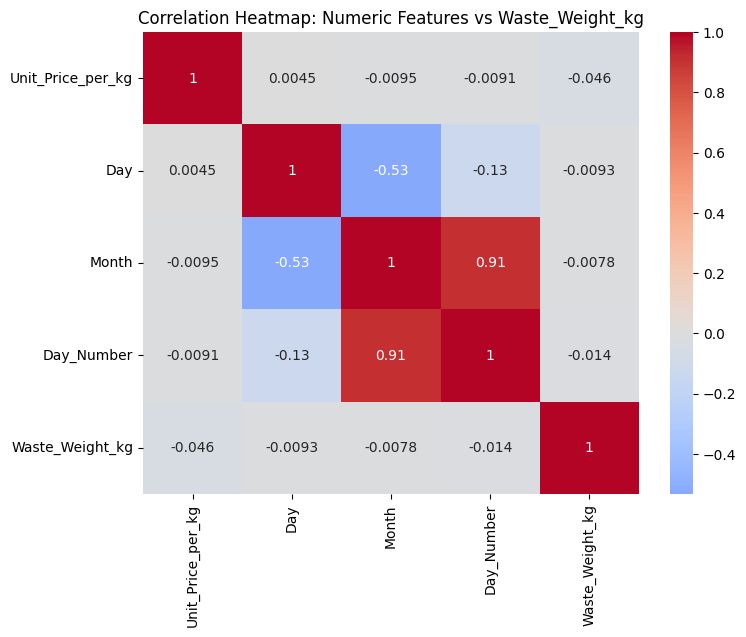

In [8]:
numeric_cols = ["Unit_Price_per_kg", "Day", "Month", "Day_Number"]

corr_with_target = df[numeric_cols + ["Waste_Weight_kg"]].corr()["Waste_Weight_kg"].sort_values(ascending=False)
print("Correlation with Waste_Weight_kg:")
print(corr_with_target)

plt.figure(figsize=(8, 6))
sns.heatmap(
    df[numeric_cols + ["Waste_Weight_kg"]].corr(),
    annot=True,
    cmap="coolwarm",
    center=0
)
plt.title("Correlation Heatmap: Numeric Features vs Waste_Weight_kg")
plt.show()

### Compare current class sizes vs. what quantile-based (equal-size) bins would look like

In [27]:
q33, q66 = df["Waste_Weight_kg"].quantile([0.33, 0.66])
print(f"Quantile-based cutoffs would be: {q33:.2f} (Low/Medium), {q66:.2f} (Medium/High)")
print(f"Your current cutoffs are: 1.7 (Low/Medium), 3.5 (Medium/High)")

# Apply YOUR existing cutoffs manually here (since classify_waste() hasn't been defined yet)
def classify_waste_temp(weight):
    if weight <= 1.7:
        return "Low"
    elif weight <= 3.5:
        return "Medium"
    else:
        return "High"

df["Waste_Level_Current"] = df["Waste_Weight_kg"].apply(classify_waste_temp)
df["Waste_Level_Quantile"] = pd.qcut(
    df["Waste_Weight_kg"],
    q=3,
    labels=["Low", "Medium", "High"]
)

print("\nYour current bin sizes:")
print(df["Waste_Level_Current"].value_counts())
print("\nQuantile-based bin sizes:")
print(df["Waste_Level_Quantile"].value_counts())

# Clean up temp columns so they don't interfere later
df.drop(columns=["Waste_Level_Current", "Waste_Level_Quantile"], inplace=True)

Quantile-based cutoffs would be: 1.76 (Low/Medium), 3.39 (Medium/High)
Your current cutoffs are: 1.7 (Low/Medium), 3.5 (Medium/High)

Your current bin sizes:
Waste_Level_Current
Medium    960
Low       829
High      811
Name: count, dtype: int64

Quantile-based bin sizes:
Waste_Level_Quantile
Medium    872
Low       869
High      859
Name: count, dtype: int64


##Creating classification target

In [28]:
def classify_waste(weight):
    if weight <= 1.7:
        return "Low"
    elif weight <= 3.5:
        return "Medium"
    else:
        return "High"

df["Waste_Level"] = df["Waste_Weight_kg"].apply(classify_waste)

In [29]:
df["Waste_Level"].value_counts()

,count
Waste_Level,
Medium,960
Low,829
High,811


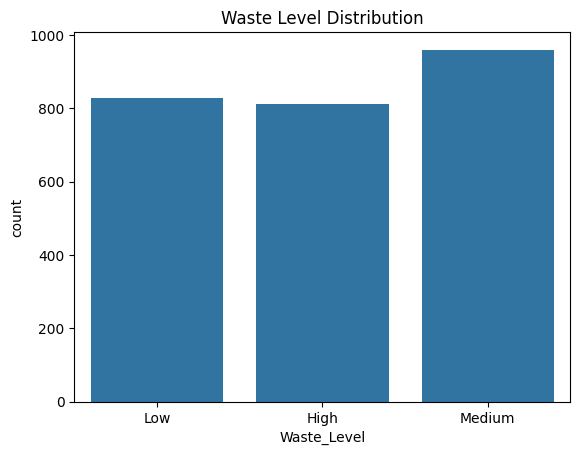

In [30]:
sns.countplot(
    data=df,
    x="Waste_Level"
)

plt.title("Waste Level Distribution")
plt.show()

##Separating Features and Target

In [31]:
X = df.drop(
    columns=[
        "Waste_Weight_kg",
        "Cost_Loss",
        "Waste_Level"
    ]
)

y = df["Waste_Level"]

print(X.shape)
print(y.shape)

(2600, 22)
(2600,)


In [32]:
X = X.astype(int)
X.head()

,Unit_Price_per_kg,Day,Month,Weekend,Day_Number,Meal_Dinner,Meal_Lunch,Food_Category_Rice,Food_Category_Soup,Food_Category_Vegetables,...,Canteen_Section_D,Day_of_Week_Monday,Day_of_Week_Saturday,Day_of_Week_Sunday,Day_of_Week_Thursday,Day_of_Week_Tuesday,Day_of_Week_Wednesday,Season_Summer,Price_Category_Medium,Price_Category_High
0,3,30,7,0,49,1,0,0,0,1,...,0,0,0,0,0,0,1,0,0,0
1,2,15,6,1,4,0,0,1,0,0,...,0,0,0,1,0,0,0,0,0,0
2,1,29,7,0,48,0,0,0,1,0,...,0,0,0,0,0,1,0,0,0,0
3,1,17,7,0,36,0,0,0,1,0,...,0,0,0,0,1,0,0,0,0,0
4,2,3,7,0,22,1,0,1,0,0,...,1,0,0,0,1,0,0,0,0,0


##Encoding Target Labels

In [33]:
encoder = LabelEncoder()
y = encoder.fit_transform(y)
print(encoder.classes_)

['High' 'Low' 'Medium']


##Train-Test Split

In [34]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42,
    stratify=y
)


print(X_train.shape)
print(X_test.shape)

(1820, 22)
(780, 22)


In [35]:
X = df.drop(
    columns=[
        "Waste_Weight_kg",
        "Cost_Loss",
        "Waste_Level"
    ]
)

##Evaluation Function

In [36]:
def evaluate_classifier(model, name):

    y_pred = model.predict(X_test)

    accuracy = accuracy_score(
        y_test,
        y_pred
    )

    precision = precision_score(
        y_test,
        y_pred,
        average="weighted"
    )

    recall = recall_score(
        y_test,
        y_pred,
        average="weighted"
    )

    f1 = f1_score(
        y_test,
        y_pred,
        average="weighted"
    )


    print(name)
    print("----------------------")
    print("Accuracy :", round(accuracy,4))
    print("Precision:", round(precision,4))
    print("Recall   :", round(recall,4))
    print("F1 Score :", round(f1,4))

    print("\nClassification Report")
    print(
        classification_report(
            y_test,
            y_pred,
            target_names=encoder.classes_
        )
    )


    return accuracy, precision, recall, f1

##Logistic Regression

In [37]:
lr_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)


lr_model.fit(
    X_train,
    y_train
)


lr_results = evaluate_classifier(
    lr_model,
    "Logistic Regression"
)

Logistic Regression
----------------------
Accuracy : 0.3577
Precision: 0.3524
Recall   : 0.3577
F1 Score : 0.3347

Classification Report
              precision    recall  f1-score   support

        High       0.34      0.19      0.24       243
         Low       0.35      0.24      0.29       249
      Medium       0.37      0.60      0.45       288

    accuracy                           0.36       780
   macro avg       0.35      0.34      0.33       780
weighted avg       0.35      0.36      0.33       780



##Decision Tree Classifier

In [38]:
from sklearn.model_selection import GridSearchCV

dt_params = {
    "max_depth":[3,5,7,10,None],
    "min_samples_split":[2,5,10],
    "min_samples_leaf":[1,5,10]
}
dt_grid = GridSearchCV(
    DecisionTreeClassifier(
        random_state=42
    ),
    param_grid=dt_params,
    cv=5,
    scoring="f1_weighted",
    n_jobs=-1
)

dt_grid.fit(
    X_train,
    y_train
)
print(dt_grid.best_params_)

dt_model = dt_grid.best_estimator_

{'max_depth': None, 'min_samples_leaf': 5, 'min_samples_split': 2}


In [39]:
dt_results = evaluate_classifier(
    dt_model,
    "Decision Tree"
)

Decision Tree
----------------------
Accuracy : 0.3397
Precision: 0.3434
Recall   : 0.3397
F1 Score : 0.3396

Classification Report
              precision    recall  f1-score   support

        High       0.31      0.38      0.34       243
         Low       0.35      0.31      0.33       249
      Medium       0.37      0.33      0.35       288

    accuracy                           0.34       780
   macro avg       0.34      0.34      0.34       780
weighted avg       0.34      0.34      0.34       780



##Random Forest Classifier

In [40]:
rf_params = {

    "n_estimators":[100,200],

    "max_depth":[5,10,15],

    "min_samples_split":[2,5,10]

}
rf_grid = GridSearchCV(
    RandomForestClassifier(
        random_state=42
    ),
    param_grid=rf_params,
    cv=5,
    scoring="f1_weighted",
    n_jobs=-1
)


rf_grid.fit(
    X_train,
    y_train
)
print(rf_grid.best_params_)

rf_model = rf_grid.best_estimator_

{'max_depth': 15, 'min_samples_split': 10, 'n_estimators': 200}


In [41]:
rf_results = evaluate_classifier(
    rf_model,
    "Random Forest"
)

Random Forest
----------------------
Accuracy : 0.3718
Precision: 0.3622
Recall   : 0.3718
F1 Score : 0.3591

Classification Report
              precision    recall  f1-score   support

        High       0.32      0.23      0.27       243
         Low       0.36      0.30      0.33       249
      Medium       0.40      0.56      0.47       288

    accuracy                           0.37       780
   macro avg       0.36      0.36      0.35       780
weighted avg       0.36      0.37      0.36       780



##Gradient Boosting Classifier

In [42]:
gb_params = {

    "n_estimators":[100,200],

    "learning_rate":[0.01,0.05,0.1],

    "max_depth":[2,3,5]

}
gb_grid = GridSearchCV(
    GradientBoostingClassifier(
        random_state=42
    ),
    param_grid=gb_params,
    cv=5,
    scoring="f1_weighted",
    n_jobs=-1
)


gb_grid.fit(
    X_train,
    y_train
)
print(gb_grid.best_params_)

gb_model = gb_grid.best_estimator_

{'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100}


In [43]:
gb_results = evaluate_classifier(
    gb_model,
    "Gradient Boosting"
)

Gradient Boosting
----------------------
Accuracy : 0.341
Precision: 0.3339
Recall   : 0.341
F1 Score : 0.3315

Classification Report
              precision    recall  f1-score   support

        High       0.33      0.24      0.28       243
         Low       0.30      0.25      0.27       249
      Medium       0.37      0.50      0.43       288

    accuracy                           0.34       780
   macro avg       0.33      0.33      0.33       780
weighted avg       0.33      0.34      0.33       780



##AdaBoost Classifier

In [44]:
ada_params = {

    "n_estimators":[50,100,200],

    "learning_rate":[0.01,0.05,0.1]

}
ada_grid = GridSearchCV(
    AdaBoostClassifier(
        random_state=42
    ),
    param_grid=ada_params,
    cv=5,
    scoring="f1_weighted",
    n_jobs=-1
)


ada_grid.fit(
    X_train,
    y_train
)
print(ada_grid.best_params_)

ada_model = ada_grid.best_estimator_

{'learning_rate': 0.1, 'n_estimators': 200}


In [45]:
ada_results = evaluate_classifier(
    ada_model,
    "AdaBoost"
)

AdaBoost
----------------------
Accuracy : 0.3679
Precision: 0.3194
Recall   : 0.3679
F1 Score : 0.253

Classification Report
              precision    recall  f1-score   support

        High       0.18      0.02      0.03       243
         Low       0.39      0.10      0.15       249
      Medium       0.37      0.90      0.53       288

    accuracy                           0.37       780
   macro avg       0.32      0.34      0.24       780
weighted avg       0.32      0.37      0.25       780



##Comparision

In [46]:
comparison = pd.DataFrame({

    "Model":[
        "Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "Gradient Boosting",
        "AdaBoost"
    ],


    "Accuracy":[
        lr_results[0],
        dt_results[0],
        rf_results[0],
        gb_results[0],
        ada_results[0]
    ],


    "Precision":[
        lr_results[1],
        dt_results[1],
        rf_results[1],
        gb_results[1],
        ada_results[1]
    ],


    "Recall":[
        lr_results[2],
        dt_results[2],
        rf_results[2],
        gb_results[2],
        ada_results[2]
    ],


    "F1 Score":[
        lr_results[3],
        dt_results[3],
        rf_results[3],
        gb_results[3],
        ada_results[3]
    ]

})


comparison.sort_values(
    by="F1 Score",
    ascending=False
)

,Model,Accuracy,Precision,Recall,F1 Score
2,Random Forest,0.371795,0.362239,0.371795,0.359113
1,Decision Tree,0.339744,0.343357,0.339744,0.339552
0,Logistic Regression,0.357692,0.352430,0.357692,0.334709
3,Gradient Boosting,0.341026,0.333924,0.341026,0.331508
4,AdaBoost,0.367949,0.319446,0.367949,0.253008


##Overfitting check

In [47]:
models = {

    "Logistic Regression":lr_model,

    "Decision Tree":dt_model,

    "Random Forest":rf_model,

    "Gradient Boosting":gb_model,

    "AdaBoost":ada_model
}


for name,model in models.items():

    train_accuracy = accuracy_score(
        y_train,
        model.predict(X_train)
    )

    test_accuracy = accuracy_score(
        y_test,
        model.predict(X_test)
    )


    print(name)
    print("Training Accuracy:",round(train_accuracy,4))
    print("Testing Accuracy :",round(test_accuracy,4))
    print()

Logistic Regression
Training Accuracy: 0.3841
Testing Accuracy : 0.3577

Decision Tree
Training Accuracy: 0.6137
Testing Accuracy : 0.3397

Random Forest
Training Accuracy: 0.7786
Testing Accuracy : 0.3718

Gradient Boosting
Training Accuracy: 0.5253
Testing Accuracy : 0.341

AdaBoost
Training Accuracy: 0.383
Testing Accuracy : 0.3679



##Feature Importance

In [48]:
importance = pd.DataFrame({
    "Feature":X.columns,
    "Importance":rf_model.feature_importances_

})

importance.sort_values(
    by="Importance",
    ascending=False
).head(10)

,Feature,Importance
1,Day,0.183072
4,Day_Number,0.180903
0,Unit_Price_per_kg,0.051747
10,Canteen_Section_B,0.051611
5,Meal_Dinner,0.048495
6,Meal_Lunch,0.047148
12,Canteen_Section_D,0.045495
11,Canteen_Section_C,0.044906
2,Month,0.042272
17,Day_of_Week_Tuesday,0.031472


##confusion matrix

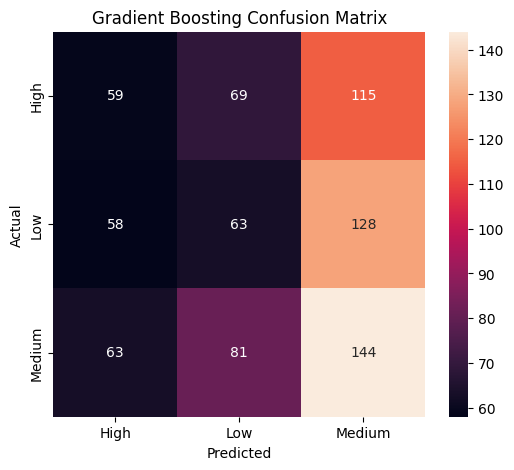

In [49]:
cm = confusion_matrix(
    y_test,
    gb_model.predict(X_test)
)


plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=encoder.classes_,
    yticklabels=encoder.classes_
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Gradient Boosting Confusion Matrix")

plt.show()

##cross-validation score

In [50]:
from sklearn.model_selection import cross_val_score


cv_scores = cross_val_score(
    gb_model,
    X,
    y,
    cv=5,
    scoring="f1_weighted"
)


print(cv_scores)
print("Average CV F1:",cv_scores.mean())

[0.33168812 0.30549337 0.35129085 0.35823654 0.32808861]
Average CV F1: 0.3349594995799013
